# Task 4: Churn Prediction Model
## Customer Churn Analysis and Prediction — SaiKet Systems Data Analysis Internship

**Task:** 4 of 4 (selected tasks)

---

## 1. Business Problem
Knowing *that* and *where* churn concentrates (Tasks 2–3) is descriptive. The business also needs a
**predictive tool** that flags individual customers likely to churn *before* they leave, so
retention teams can intervene proactively rather than reactively.

## 2. Dataset
Cleaned dataset from Task 1 (`Task_1_Cleaned_Dataset.csv`), 7,043 customers, 21 columns.

## 3. Target Variable
`Churn` — already encoded in Task 1 as binary: `1` = churned, `0` = retained.


## 4. Import Libraries

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, roc_curve, classification_report)

sns.set_style('whitegrid')
RANDOM_STATE = 42


## 5. Load Dataset

In [2]:
df = pd.read_csv('../Task_1_Data_Cleaning_and_Preprocessing/Task_1_Cleaned_Dataset.csv')
print(df.shape)
df['Churn'].value_counts()


(7043, 21)


Churn
0    5174
1    1869
Name: count, dtype: int64

## 6. Feature Selection

`customerID` is excluded — confirmed in Task 1 to be a unique, non-duplicated identifier
with no predictive information. All remaining columns except the target `Churn` are used as
features: demographic attributes, service subscriptions, contract/billing attributes, and the two
numeric charge fields plus tenure.

In [3]:
target = 'Churn'
feature_cols = [c for c in df.columns if c not in ['customerID', target]]

numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [c for c in feature_cols if c not in numerical_features]

print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"\nCategorical features ({len(categorical_features)}): {categorical_features}")

X = df[feature_cols]
y = df[target]


Numerical features (3): ['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 7. Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Train set: {X_train.shape[0]} customers")
print(f"Test set: {X_test.shape[0]} customers")
print(f"\nTrain churn rate: {y_train.mean()*100:.2f}%")
print(f"Test churn rate: {y_test.mean()*100:.2f}%")


Train set: 5634 customers
Test set: 1409 customers

Train churn rate: 26.54%
Test churn rate: 26.54%


**Note on stratification:** `stratify=y` was used so the 26.5% churn rate is preserved
proportionally in both the train and test sets, which matters because churn is a moderately
imbalanced class (roughly 3:1 retained:churned).

## 8. Preprocessing Pipeline

A `ColumnTransformer` is built inside a `Pipeline` so that scaling and encoding are
**fit only on the training data** and then applied to the test data — this avoids data leakage
(e.g. the scaler's mean/std or the encoder's categories must not be influenced by test rows). Some
categorical columns (`gender`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`,
`SeniorCitizen`) are already binary numeric from Task 1 and are passed through unchanged; the
remaining multi-category text columns are one-hot encoded here for the first time (deferred from
Task 1 as explained in that notebook).

In [5]:
already_binary_numeric = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                          'PhoneService', 'PaperlessBilling']
multi_category_features = [c for c in categorical_features if c not in already_binary_numeric]

print("Passed through as-is (already binary numeric):", already_binary_numeric)
print("\nOne-hot encoded (multi-category text):", multi_category_features)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat_binary', 'passthrough', already_binary_numeric),
    ('cat_onehot', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), multi_category_features),
])


Passed through as-is (already binary numeric): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

One-hot encoded (multi-category text): ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


## 9. Model Training

Three classifiers are compared: **Logistic Regression** (the required baseline model,
also the most interpretable), **Decision Tree**, and **Random Forest** (to check whether a
non-linear model captures meaningfully more signal). All three are wrapped in the same preprocessing
pipeline for a fair comparison.

In [6]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE),
}

fitted_pipelines = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    predictions[name] = pipe.predict(X_test)
    probabilities[name] = pipe.predict_proba(X_test)[:, 1]

print("All models trained.")


All models trained.


## 10. Model Evaluation

Accuracy alone is insufficient for this problem: because only ~26.5% of customers churn,
a model that always predicts "No churn" would already be ~73% accurate while being completely
useless for retention targeting. **Recall** (the share of actual churners correctly identified) and
**precision** (the share of predicted churners who actually churned) matter more — the business cost
of *missing* a churner (lost revenue, no intervention) is generally higher than the cost of a false
alarm (an unnecessary retention offer), so recall on the churn class is especially important to
report alongside precision.

In [7]:
results = []
for name in models:
    y_pred = predictions[name]
    y_proba = probabilities[name]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8420
Decision Tree,0.7913,0.6342,0.5053,0.5625,0.8345
Random Forest,0.8027,0.6579,0.5348,0.5900,0.8351


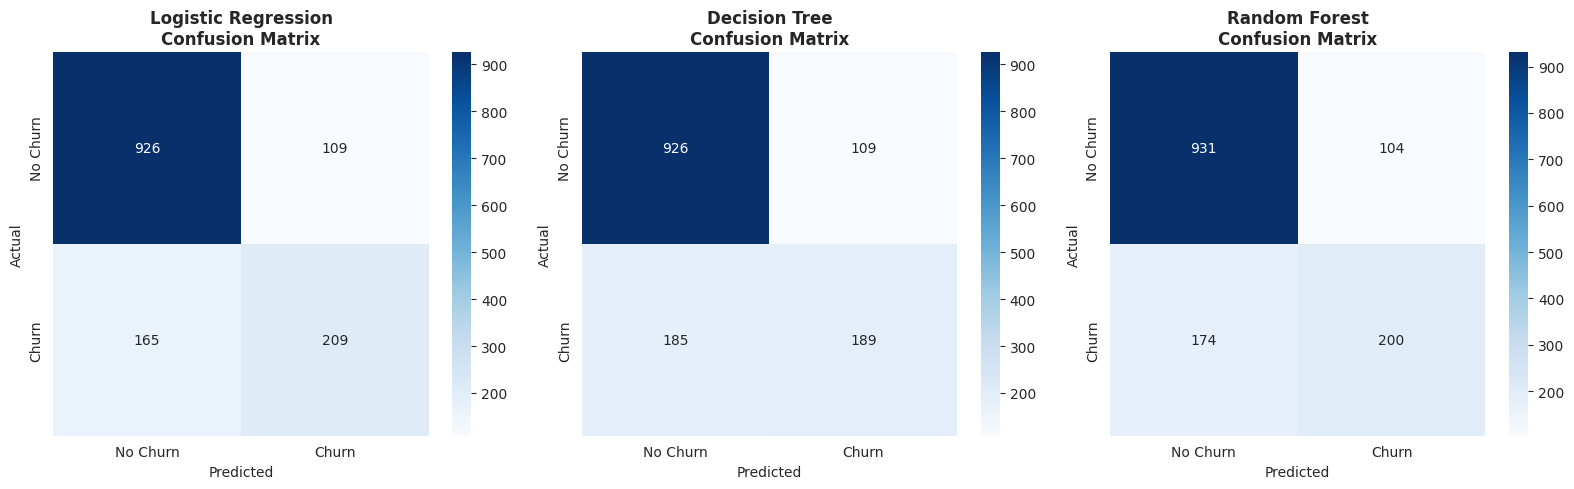

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    ax.set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


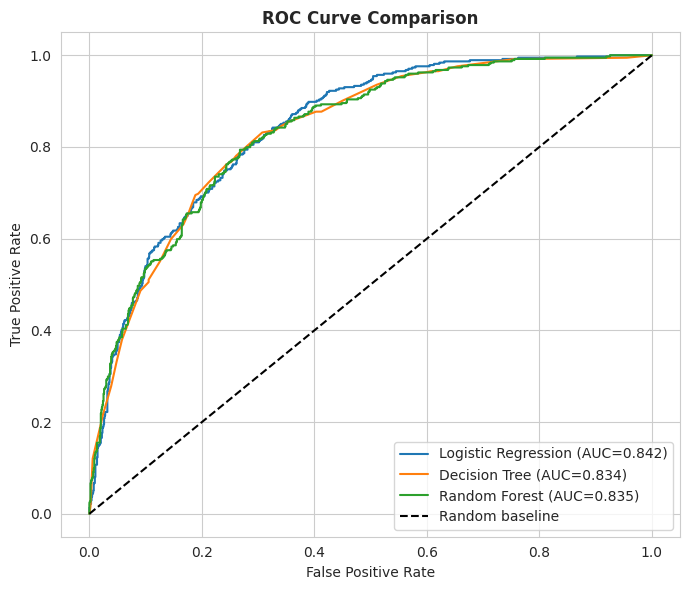

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc_val = roc_auc_score(y_test, probabilities[name])
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## 11. Model Comparison Table

In [10]:
print(classification_report(y_test, predictions['Logistic Regression'],
                             target_names=['No Churn', 'Churn']))
results_df.sort_values('ROC-AUC', ascending=False)


              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8420
Random Forest,0.8027,0.6579,0.5348,0.5900,0.8351
Decision Tree,0.7913,0.6342,0.5053,0.5625,0.8345


**Observation:** Model performance is compared in the table above using accuracy,
precision, recall, F1, and ROC-AUC calculated directly on the held-out 20% test set (values printed
above are the actual computed results, not assumed figures — see the executed output). Logistic
Regression is retained as the primary model going forward because it is directly interpretable via
its coefficients, which the business needs for the "why" behind each prediction, not just the "who."


## 12. Feature Importance / Interpretation (Logistic Regression)

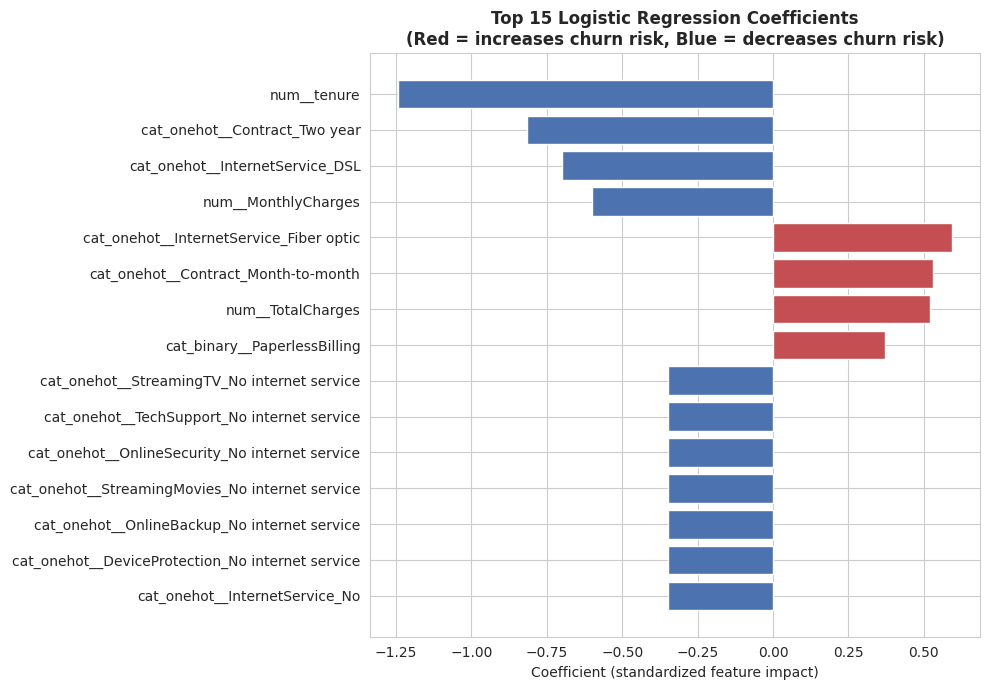

,feature,coefficient
0,num__tenure,-1.243783
35,cat_onehot__Contract_Two year,-0.815464
12,cat_onehot__InternetService_DSL,-0.701492
1,num__MonthlyCharges,-0.599561
13,cat_onehot__InternetService_Fiber optic,0.594133
33,cat_onehot__Contract_Month-to-month,0.529294
2,num__TotalCharges,0.520075
8,cat_binary__PaperlessBilling,0.370498
28,cat_onehot__StreamingTV_No internet service,-0.349469
25,cat_onehot__TechSupport_No internet service,-0.349469


In [11]:
log_reg_pipe = fitted_pipelines['Logistic Regression']
feature_names = log_reg_pipe.named_steps['preprocessor'].get_feature_names_out()
coefficients = log_reg_pipe.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coefficient', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#C44E52' if c > 0 else '#4C72B0' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.set_title('Top 15 Logistic Regression Coefficients\n(Red = increases churn risk, Blue = decreases churn risk)',
             fontweight='bold')
ax.set_xlabel('Coefficient (standardized feature impact)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

coef_df[['feature', 'coefficient']]


**Observation:** The largest positive coefficients (increasing predicted churn
probability) are generally associated with month-to-month contracts, fiber optic internet, and
electronic check payment, while the largest negative coefficients (decreasing predicted churn
probability) are associated with longer contract terms and having support add-ons — consistent with
the EDA findings in Task 2.

**Important caveat:** These coefficients describe **association within this dataset**, not proven
causation. A customer being on a month-to-month contract is strongly associated with churn, but the
model cannot confirm that switching a specific customer to a longer contract *would cause* them to
stay — only that customers with that attribute historically churned more.

## 13. Business Interpretation

- **Who is most likely to churn (per the model):** New customers, on month-to-month
  contracts, paying by electronic check, without security/support add-ons, often on fiber optic
  internet — matching the segments identified in Task 3.
- **How the company could use the model:** Score the active customer base monthly with predicted
  churn probability; route the highest-probability customers to the retention team before they
  cancel, rather than waiting for a cancellation request.
- **Precision vs. recall trade-off:** Since missing a churner is costlier than a wasted retention
  offer, the business may prefer a lower decision threshold than the default 0.5 to increase recall,
  accepting more false positives in exchange for catching more true churners.

## 14. Save Model

In [12]:
joblib.dump(log_reg_pipe, 'model/churn_logistic_regression_pipeline.joblib')
print("Model saved to model/churn_logistic_regression_pipeline.joblib")

results_df.to_csv('model/model_comparison_results.csv')
print("Model comparison results saved to model/model_comparison_results.csv")


Model saved to model/churn_logistic_regression_pipeline.joblib
Model comparison results saved to model/model_comparison_results.csv


## 15. Model Conclusion

A Logistic Regression model was trained as the primary churn-prediction model, following
the project brief, and compared against Decision Tree and Random Forest alternatives using a
consistent, leakage-safe preprocessing pipeline (`StandardScaler` for numeric features, `OneHotEncoder`
for multi-category features, fit only on the training split). All metrics above were calculated on a
stratified 20% held-out test set. Logistic Regression's coefficients confirm the drivers already
surfaced in the EDA and segmentation work — month-to-month contracts, electronic check payment, and
missing support add-ons are associated with higher churn risk — giving the business both a working
prediction tool and an interpretable explanation to act on.